# 知识图谱构建教学案例
## -- 基于 PrimeKG 生物医学知识图谱 Demo 数据集

---

## 本案例学习目标

1. **理解知识图谱的基本概念**：节点、边、关系类型
2. **掌握知识图谱的数据来源与格式**：三元组 (头实体, 关系, 尾实体)
3. **学会构建知识图谱**：从原始数据到图结构
4. **掌握图谱统计分析**：度分布、中心性、连通性
5. **实现知识图谱可视化**：直观展示图谱结构

---

## Demo 数据集说明

本案例使用的数据文件为 **`kg_demo.csv`**，是从 PrimeKG 完整数据集中抽取的一个小型演示子集，供教学演示使用。

### 原始数据集：PrimeKG

**PrimeKG（Precision Medicine Knowledge Graph）** 是一个生物医学领域的大规模知识图谱，  
由哈佛大学 Zitnik Lab 构建，整合了来自 **20 个生物医学数据库**的数据。

| 项目 | 信息 |
|------|------|
| 论文 | Chandak et al., *"Precision Medicine Knowledge Graph"*, Nature Scientific Data, 2023 |
| 数据下载 | https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/IXA7BM |
| GitHub | https://github.com/mims-harvard/PrimeKG |
| 完整规模 | 8,100,498 条三元组，129,375 个实体，18 种关系类型 |

> **如需深入学习，可前往上方链接下载完整数据集。** 本案例仅使用 Demo 子集进行演示教学。

---

### Demo 子集的构建方式

为保证演示图谱的可视化效果（节点高度共享、结构紧密），Demo 数据通过以下策略从完整数据集中采样：

1. 选取跨越最多关系类型的「枢纽节点」作为锚点（如 Acetaminophen、Doxorubicin、ABCB1 等）
2. 每种关系类型优先采样含锚点的边，共采样约 30 条
3. 最终得到覆盖 **全部 18 种关系类型** 的紧密子图

| 项目 | Demo 数据集 | 完整 PrimeKG |
|------|------------|-------------|
| 三元组数量 | 540 条 | 8,100,498 条 |
| 实体节点数 | ~545 个 | ~129,375 个 |
| 关系类型数 | 18 种（全覆盖）| 18 种 |
| 文件大小 | ~43 KB | ~1.4 GB |

---

### Demo 数据集的实体类型

| 实体类型 | 说明 | 示例 |
|---------|------|------|
| `gene/protein` | 基因/蛋白质 | TP53, ABCB1, CYP3A4 |
| `drug` | 药物 | Acetaminophen, Morphine |
| `disease` | 疾病 | Hypertension, Cancer |
| `effect/phenotype` | 表型/副作用 | Headache, Nausea |
| `anatomy` | 解剖结构 | Liver, Brain |
| `biological_process` | 生物过程 | Cell apoptosis |
| `molecular_function` | 分子功能 | Enzyme activity |
| `cellular_component` | 细胞组件 | Mitochondria |
| `exposure` | 暴露因素 | Tobacco smoke |

---
## 第一步：环境准备

In [1]:
# 安装所需库（如已安装可跳过）
# !pip install pandas networkx matplotlib seaborn pyvis

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import defaultdict, Counter
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体（Windows）
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

print('环境准备完成！')
print(f'NetworkX 版本: {nx.__version__}')
print(f'Pandas 版本: {pd.__version__}')

环境准备完成！
NetworkX 版本: 3.5
Pandas 版本: 2.3.3


---
## 第二步：加载与探索 Demo 数据

### 知识点：知识图谱的三元组表示

知识图谱的核心数据结构是**三元组**：

$$\text{(头实体, 关系, 尾实体)} \quad \Leftrightarrow \quad (h, r, t)$$

例如：`(Acetaminophen, target, PTGS2)` 表示「对乙酰氨基酚以 PTGS2 蛋白为靶点」

### kg_demo.csv 字段说明

| 字段 | 含义 | 示例 |
|------|------|------|
| `relation` | 关系的内部编码名称 | `drug_protein` |
| `display_relation` | 关系的展示名称 | `target` |
| `x_name` | **头实体**名称（三元组的起点）| `Acetaminophen` |
| `x_type` | 头实体的类型 | `drug` |
| `y_name` | **尾实体**名称（三元组的终点）| `PTGS2` |
| `y_type` | 尾实体的类型 | `gene/protein` |

In [2]:
# 直接加载 Demo 数据集（小文件，秒级加载）
DATA_PATH = 'kg_demo.csv'

df_sample = pd.read_csv(DATA_PATH)
print(f'Demo 数据加载完成！共 {len(df_sample):,} 条三元组')
print()
print('数据前 5 行：')
df_sample.head()

Demo 数据加载完成！共 540 条三元组

数据前 5 行：


,relation,display_relation,x_type,x_name,y_type,y_name
0,disease_protein,associated with,gene/protein,TP53,disease,adrenal cortex carcinoma
1,disease_protein,associated with,disease,spindle cell sarcoma,gene/protein,TP53
2,disease_protein,associated with,gene/protein,TP53,disease,head and neck cancer
3,disease_protein,associated with,gene/protein,TP53,disease,skin carcinoma
4,disease_protein,associated with,gene/protein,ABCB1,disease,kidney cancer


In [3]:
# Demo 数据集统计，并与完整 PrimeKG 对比
total_edges  = len(df_sample)
all_nodes    = pd.concat([df_sample['x_name'], df_sample['y_name']]).nunique()
n_rel_types  = df_sample['display_relation'].nunique()
n_node_types = pd.concat([df_sample['x_type'], df_sample['y_type']]).nunique()

print('=' * 55)
print('       数据集规模对比')
print('=' * 55)
print(f'  {"指标":<20} {"Demo (kg_demo.csv)":>16} {"完整 PrimeKG":>14}')
print(f'  {"-"*52}')
print(f'  {"三元组（边）数量":<20} {total_edges:>16,} {"8,100,498":>14}')
print(f'  {"实体（节点）数量":<20} {all_nodes:>16,} {"~129,375":>14}')
print(f'  {"关系类型数":<20} {n_rel_types:>16} {"18":>14}')
print(f'  {"实体类型数":<20} {n_node_types:>16} {"9":>14}')
print('=' * 55)
print()
print('各关系类型在 Demo 中的分布：')
print(df_sample['display_relation'].value_counts().to_string())

       数据集规模对比
  指标                   Demo (kg_demo.csv)     完整 PrimeKG
  ----------------------------------------------------
  三元组（边）数量                          540      8,100,498
  实体（节点）数量                          545       ~129,375
  关系类型数                              18             18
  实体类型数                              10              9

各关系类型在 Demo 中的分布：
display_relation
associated with            30
carrier                    30
contraindication           30
enzyme                     30
expression absent          30
expression present         30
indication                 30
interacts with             30
linked to                  30
off-label use              30
parent-child               30
phenotype absent           30
phenotype present          30
ppi                        30
side effect                30
synergistic interaction    30
target                     30
transporter                30


---
## 第三步：关系类型统计分析

### 知识点：知识图谱的多关系特性

不同于简单网络，知识图谱中的边带有**语义标签（关系类型）**。  
同一对实体之间可能存在不同类型的关系，这使得知识图谱能表达更丰富的语义信息。

PrimeKG 的 18 种关系类型覆盖的语义层次：

```
         暴露     药物          基因/蛋白质       疾病         表型
          |        |                 |              |            |
 linked_to|   target/enzyme         ppi        indication  phenotype_present
          |   side_effect      associated_with  contraindication
          |   synergistic      expression       parent-child
          |   carrier/transporter  interacts_with
```

> **Demo 说明**：Demo 数据中每种关系类型约 30 条，数量较为均衡。  
> 完整 PrimeKG 中各关系类型数量差异悬殊，最多的 `expression present` 有 300 万条，最少的 `carrier` 仅 1728 条。

In [4]:
# 统计 Demo 数据中每种关系类型的数量，并附中文含义

# 关系类型中文对照表
rel_desc = {
    'ppi':                     '蛋白质-蛋白质相互作用',
    'expression present':      '基因在解剖位置表达（存在）',
    'expression absent':       '基因在解剖位置不表达（缺失）',
    'synergistic interaction':  '药物-药物协同作用',
    'associated with':         '基因/表型与疾病关联',
    'interacts with':          '基因/蛋白与GO功能互作',
    'parent-child':            '本体层级父子关系',
    'phenotype present':       '疾病具有该表型',
    'phenotype absent':        '疾病不具有该表型',
    'side effect':             '药物副作用',
    'contraindication':        '药物禁忌症',
    'indication':              '药物适应症',
    'target':                  '药物靶点',
    'enzyme':                  '药物代谢酶',
    'transporter':             '药物转运体',
    'carrier':                 '药物载体蛋白',
    'off-label use':           '超说明书使用',
    'linked to':               '暴露因素与疾病关联',
}

rel_counts = df_sample['display_relation'].value_counts().reset_index()
rel_counts.columns = ['关系类型', '三元组数量（Demo）']

# 完整 PrimeKG 中的数量（供参考）
full_kg_counts = {
    'expression present': 3036406, 'synergistic interaction': 2672628,
    'interacts with': 686550, 'ppi': 642150, 'phenotype present': 300634,
    'parent-child': 281744, 'associated with': 167482, 'side effect': 129568,
    'contraindication': 61350, 'expression absent': 39774, 'target': 32760,
    'indication': 18776, 'enzyme': 10634, 'transporter': 6184,
    'off-label use': 5136, 'linked to': 4608, 'phenotype absent': 2386, 'carrier': 1728,
}
rel_counts['完整PrimeKG数量'] = rel_counts['关系类型'].map(full_kg_counts)
rel_counts['中文含义'] = rel_counts['关系类型'].map(rel_desc)

print('Demo 数据关系类型统计（附完整 PrimeKG 数量对比）：')
print(rel_counts.to_string(index=False))

Demo 数据关系类型统计（附完整 PrimeKG 数量对比）：
                   关系类型  三元组数量（Demo）  完整PrimeKG数量           中文含义
        associated with           30       167482     基因/表型与疾病关联
                carrier           30         1728         药物载体蛋白
       contraindication           30        61350          药物禁忌症
                 enzyme           30        10634          药物代谢酶
      expression absent           30        39774 基因在解剖位置不表达（缺失）
     expression present           30      3036406  基因在解剖位置表达（存在）
             indication           30        18776          药物适应症
         interacts with           30       686550   基因/蛋白与GO功能互作
              linked to           30         4608      暴露因素与疾病关联
          off-label use           30         5136         超说明书使用
           parent-child           30       281744       本体层级父子关系
       phenotype absent           30         2386       疾病不具有该表型
      phenotype present           30       300634        疾病具有该表型
                    ppi           30       642150    蛋白质-

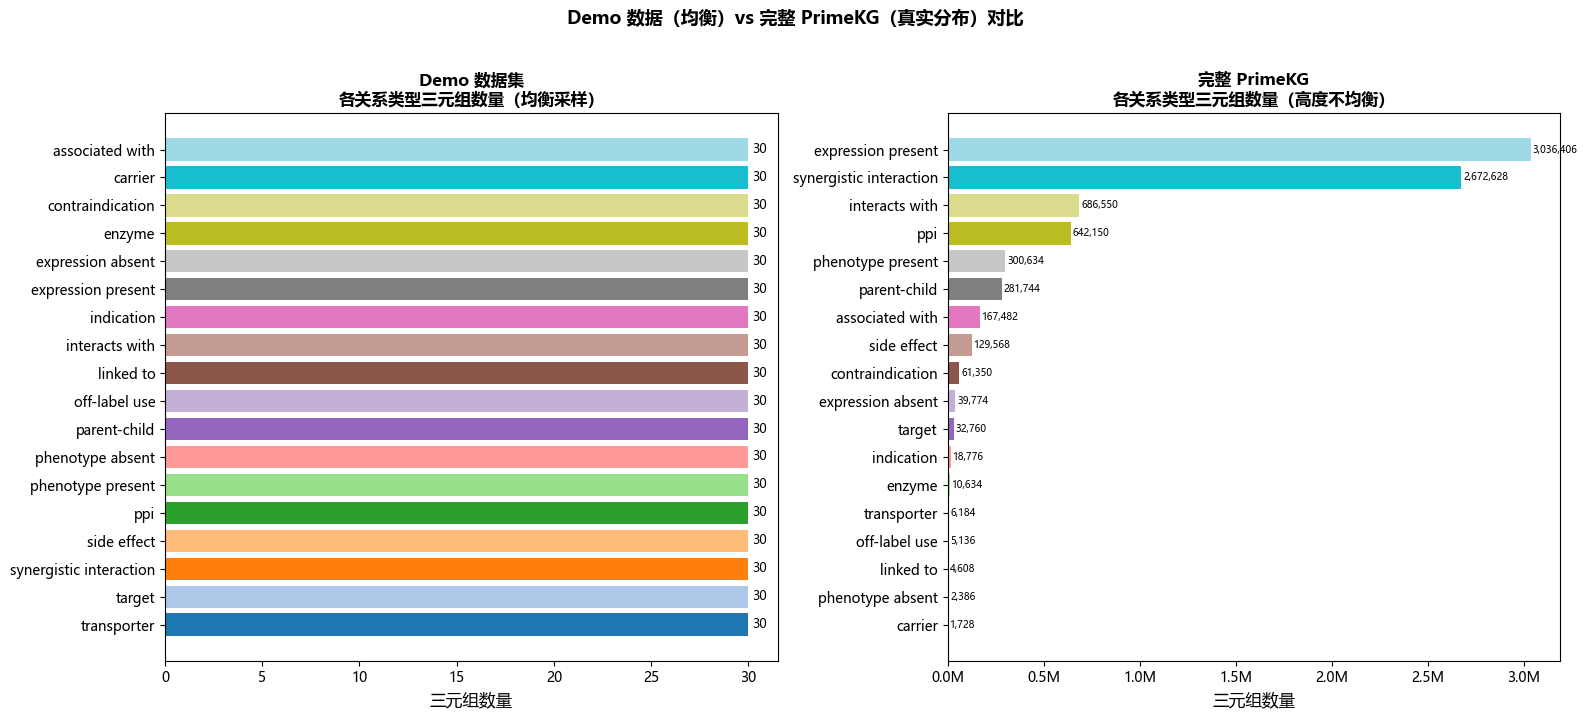

图表已保存至 relation_distribution.png


In [5]:
# 可视化：Demo vs 完整 PrimeKG 关系类型分布对比

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

colors = plt.cm.tab20(np.linspace(0, 1, len(rel_counts)))

# 左图：Demo 数据中各关系类型数量（均衡采样）
bars_demo = axes[0].barh(rel_counts['关系类型'][::-1],
                          rel_counts['三元组数量（Demo）'][::-1],
                          color=colors)
axes[0].set_xlabel('三元组数量', fontsize=12)
axes[0].set_title('Demo 数据集\n各关系类型三元组数量（均衡采样）',
                   fontsize=12, fontweight='bold')
for bar, val in zip(bars_demo, rel_counts['三元组数量（Demo）'][::-1]):
    axes[0].text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                 str(val), va='center', fontsize=9)

# 右图：完整 PrimeKG 中各关系类型数量（悬殊分布）
full_sorted = sorted(full_kg_counts.items(), key=lambda x: x[1])
full_names  = [x[0] for x in full_sorted]
full_vals   = [x[1] for x in full_sorted]
colors2 = plt.cm.tab20(np.linspace(0, 1, len(full_sorted)))
bars_full = axes[1].barh(full_names, full_vals, color=colors2)
axes[1].set_xlabel('三元组数量', fontsize=12)
axes[1].set_title('完整 PrimeKG\n各关系类型三元组数量（高度不均衡）',
                   fontsize=12, fontweight='bold')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
for bar, val in zip(bars_full, full_vals):
    axes[1].text(bar.get_width() + 10000, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=7)

plt.suptitle('Demo 数据（均衡）vs 完整 PrimeKG（真实分布）对比',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('relation_distribution.png', bbox_inches='tight', dpi=120)
plt.show()
print('图表已保存至 relation_distribution.png')

---
## 第四步：构建知识图谱

### 知识点：图（Graph）的数据结构

知识图谱本质上是一个**有向异质图（Directed Heterogeneous Graph）**：

- **节点（Node）**：实体，带有 `type`（实体类型）等属性
- **边（Edge）**：关系，带有 `relation`（关系类型）等属性
- **有向**：关系有方向，如「药物 -> 靶点」
- **异质**：节点/边均有类型标签
- **多重**：同一对节点间可能有多种关系

我们使用 **NetworkX** 库中的 `MultiDiGraph`（多重有向图）来构建。

```
节点属性示例：
  Acetaminophen  { node_type: "drug" }
  PTGS2          { node_type: "gene/protein" }

边属性示例：
  Acetaminophen --[target]--> PTGS2
  Acetaminophen --[enzyme]--> CYP3A4
  Acetaminophen --[indication]--> Headache
```

In [6]:
# 4.1 构建 NetworkX 多重有向图

G = nx.MultiDiGraph(name='PrimeKG-Demo')

# 批量添加节点（带类型属性）
for name, ntype in zip(df_sample['x_name'], df_sample['x_type']):
    G.add_node(name, node_type=ntype)
for name, ntype in zip(df_sample['y_name'], df_sample['y_type']):
    G.add_node(name, node_type=ntype)

# 批量添加边（带关系属性）
for _, row in df_sample.iterrows():
    G.add_edge(row['x_name'], row['y_name'],
               relation=row['display_relation'],
               relation_full=row['relation'])

# 构建无向简单图（用于度/连通性分析）
G_simple = nx.Graph()
G_simple.add_nodes_from(G.nodes(data=True))
for u, v in G.edges():
    G_simple.add_edge(u, v)

components = list(nx.connected_components(G_simple))
largest_cc = max(components, key=len)
G_lcc = G_simple.subgraph(largest_cc).copy()

print('=' * 50)
print('       知识图谱基本信息')
print('=' * 50)
print(f'  节点数（实体数）:       {G.number_of_nodes():>6}')
print(f'  边数（三元组数）:       {G.number_of_edges():>6}')
print(f'  平均出度:               {np.mean([d for _, d in G.out_degree()]):>6.2f}')
print(f'  连通分量数:             {len(components):>6}')
print(f'  最大连通分量节点数:     {len(largest_cc):>6}')
print('=' * 50)

       知识图谱基本信息
  节点数（实体数）:          545
  边数（三元组数）:          540
  平均出度:                 0.99
  连通分量数:                 60
  最大连通分量节点数:        407


In [7]:
# 4.2 展示各关系类型的三元组示例

print('各关系类型三元组示例（每种 3 条）：')
print()
for rel_type, grp in df_sample.groupby('display_relation'):
    print(f'  [{rel_type}]  ({rel_desc.get(rel_type, "")})')
    for _, r in grp.head(3).iterrows():
        print(f'    ({r["x_type"]}) {r["x_name"]:22s} --[{rel_type}]--> '
              f'{r["y_name"]} ({r["y_type"]})')
    print()

各关系类型三元组示例（每种 3 条）：

  [associated with]  (基因/表型与疾病关联)
    (gene/protein) TP53                   --[associated with]--> adrenal cortex carcinoma (disease)
    (disease) spindle cell sarcoma   --[associated with]--> TP53 (gene/protein)
    (gene/protein) TP53                   --[associated with]--> head and neck cancer (disease)

  [carrier]  (药物载体蛋白)
    (gene/protein) ALB                    --[carrier]--> Chlorpromazine (drug)
    (drug) Naloxone               --[carrier]--> ALB (gene/protein)
    (gene/protein) ALB                    --[carrier]--> Miconazole (drug)

  [contraindication]  (药物禁忌症)
    (disease) congenital hypothyroidism --[contraindication]--> Morphine (drug)
    (drug) Nicotine               --[contraindication]--> acute coronary syndrome (disease)
    (disease) type 1 diabetes mellitus --[contraindication]--> Nicotine (drug)

  [enzyme]  (药物代谢酶)
    (drug) Fulvestrant            --[enzyme]--> CYP3A4 (gene/protein)
    (gene/protein) CYP3A4                 --[enzyme

---
## 第五步：图谱统计特征分析

### 知识点：图的基本统计特征

| 指标 | 定义 | 意义 |
|------|------|------|
| **度（Degree）** | 节点连接的边数 | 节点的「重要性」 |
| **度中心性** | 归一化的度 | 在图中的影响力 |
| **介数中心性** | 经过该节点最短路径的比例 | 信息传递的关键枢纽 |
| **幂律分布** | P(k) ~ k^(-γ) | 真实网络的普遍特征，少数节点连接极多 |

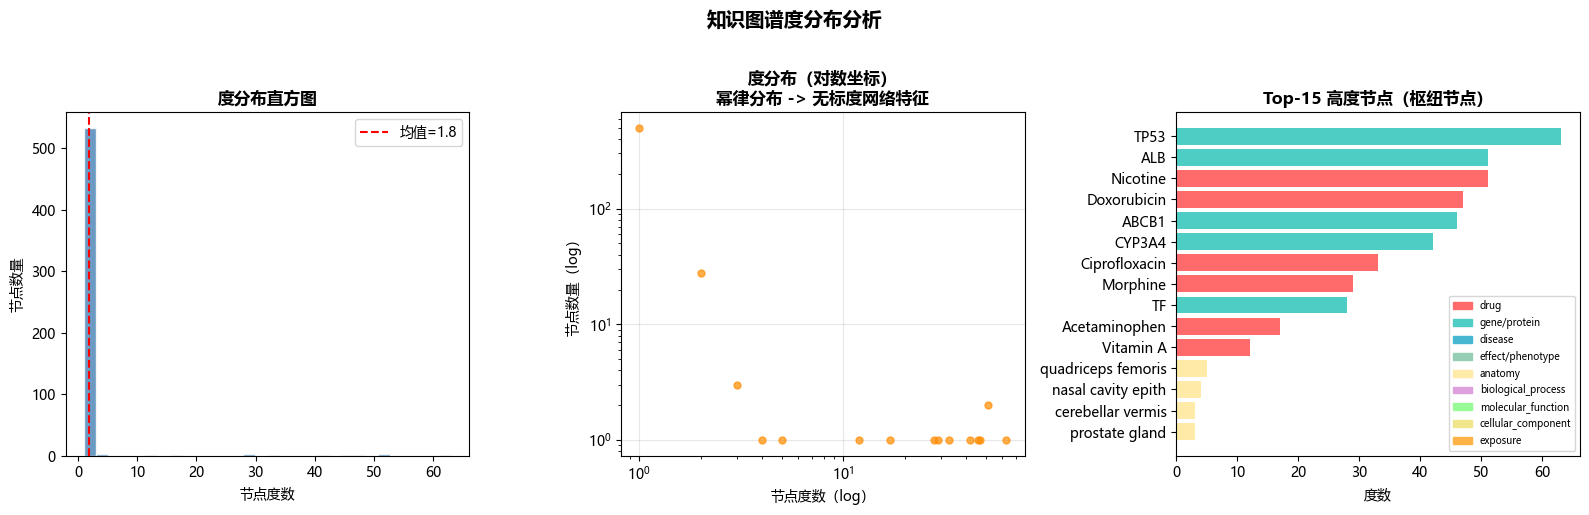

In [8]:
# 6.1 度分布分析

node_type_colors = {
    'drug':               '#FF6B6B',
    'gene/protein':       '#4ECDC4',
    'disease':            '#45B7D1',
    'effect/phenotype':   '#96CEB4',
    'anatomy':            '#FFEAA7',
    'biological_process': '#DDA0DD',
    'molecular_function': '#98FB98',
    'cellular_component': '#F0E68C',
    'exposure':           '#FFB347',
}

degrees    = dict(G_simple.degree())
deg_values = list(degrees.values())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 左：度分布直方图
axes[0].hist(deg_values, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('节点度数')
axes[0].set_ylabel('节点数量')
axes[0].set_title('度分布直方图', fontweight='bold')
axes[0].axvline(np.mean(deg_values), color='red', linestyle='--',
                label=f'均值={np.mean(deg_values):.1f}')
axes[0].legend()

# 中：对数坐标（检验幂律）
deg_counter = Counter(deg_values)
x_deg = sorted(deg_counter.keys())
y_cnt = [deg_counter[d] for d in x_deg]
axes[1].loglog(x_deg, y_cnt, 'o', color='darkorange', alpha=0.7, markersize=5)
axes[1].set_xlabel('节点度数（log）')
axes[1].set_ylabel('节点数量（log）')
axes[1].set_title('度分布（对数坐标）\n幂律分布 -> 无标度网络特征', fontweight='bold')
axes[1].grid(True, alpha=0.3)

# 右：Top-15 高度节点
top15 = sorted(degrees.items(), key=lambda x: x[1], reverse=True)[:15]
bar_colors = [
    node_type_colors.get(G_simple.nodes[n].get('node_type', ''), '#cccccc')
    for n, _ in top15
]
axes[2].barh([x[0][:18] for x in top15][::-1],
             [x[1] for x in top15][::-1],
             color=bar_colors[::-1])
axes[2].set_xlabel('度数')
axes[2].set_title('Top-15 高度节点（枢纽节点）', fontweight='bold')
legend_patches = [mpatches.Patch(color=c, label=t)
                  for t, c in node_type_colors.items()]
axes[2].legend(handles=legend_patches, loc='lower right', fontsize=7)

plt.suptitle('知识图谱度分布分析', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('degree_analysis.png', bbox_inches='tight', dpi=120)
plt.show()

在最大连通分量上计算中心性（407 节点）...

Top-10 度中心性节点：
           节点         节点类型     度中心性    介数中心性
         TP53 gene/protein 0.155172 0.273383
          ALB gene/protein 0.125616 0.382212
     Nicotine         drug 0.125616 0.340100
  Doxorubicin         drug 0.115764 0.228164
        ABCB1 gene/protein 0.113300 0.344457
       CYP3A4 gene/protein 0.103448 0.220512
Ciprofloxacin         drug 0.081281 0.250670
     Morphine         drug 0.071429 0.212395
           TF gene/protein 0.068966 0.156120
Acetaminophen         drug 0.041872 0.078314


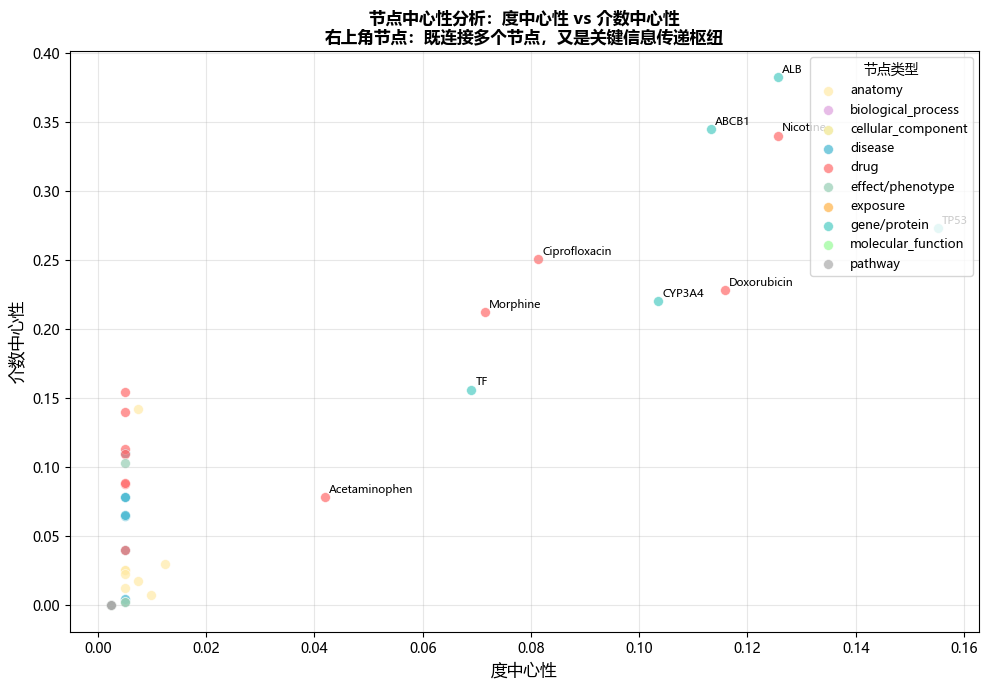

In [9]:
# 6.2 中心性分析

print(f'在最大连通分量上计算中心性（{G_lcc.number_of_nodes()} 节点）...')

degree_centrality      = nx.degree_centrality(G_lcc)
betweenness_centrality = nx.betweenness_centrality(
    G_lcc, k=min(100, G_lcc.number_of_nodes()), seed=42)

centrality_df = pd.DataFrame({
    '节点':    list(degree_centrality.keys()),
    '度中心性': list(degree_centrality.values()),
    '介数中心性': [betweenness_centrality.get(n, 0)
                   for n in degree_centrality],
    '节点类型': [G_lcc.nodes[n].get('node_type', 'unknown')
                 for n in degree_centrality],
}).sort_values('度中心性', ascending=False)

print('\nTop-10 度中心性节点：')
print(centrality_df[['节点', '节点类型', '度中心性', '介数中心性']]
      .head(10).to_string(index=False))

# 散点图
fig, ax = plt.subplots(figsize=(10, 7))
for ntype, grp in centrality_df.groupby('节点类型'):
    ax.scatter(grp['度中心性'], grp['介数中心性'],
               c=node_type_colors.get(ntype, '#aaaaaa'), label=ntype,
               alpha=0.7, s=50, edgecolors='white', linewidth=0.5)

for _, row in centrality_df.head(10).iterrows():
    ax.annotate(row['节点'][:18], (row['度中心性'], row['介数中心性']),
                fontsize=8, xytext=(3, 3), textcoords='offset points')

ax.set_xlabel('度中心性', fontsize=12)
ax.set_ylabel('介数中心性', fontsize=12)
ax.set_title('节点中心性分析：度中心性 vs 介数中心性\n'
             '右上角节点：既连接多个节点，又是关键信息传递枢纽',
             fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=9, title='节点类型')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('centrality_analysis.png', bbox_inches='tight', dpi=120)
plt.show()

---
## 第六步：知识图谱可视化

### 知识点：图可视化的挑战与策略

- 节点过多时图会变得混乱（"Hairball Problem"）
- 解决方案：**聚焦核心子图**、**按节点类型着色**、**边颜色区分关系**
- 常用布局算法：Spring（力导向）、Circular（环形）、Hierarchical（层次）
- 常用可视化工具：**matplotlib**（静态）、**pyvis**（交互式）

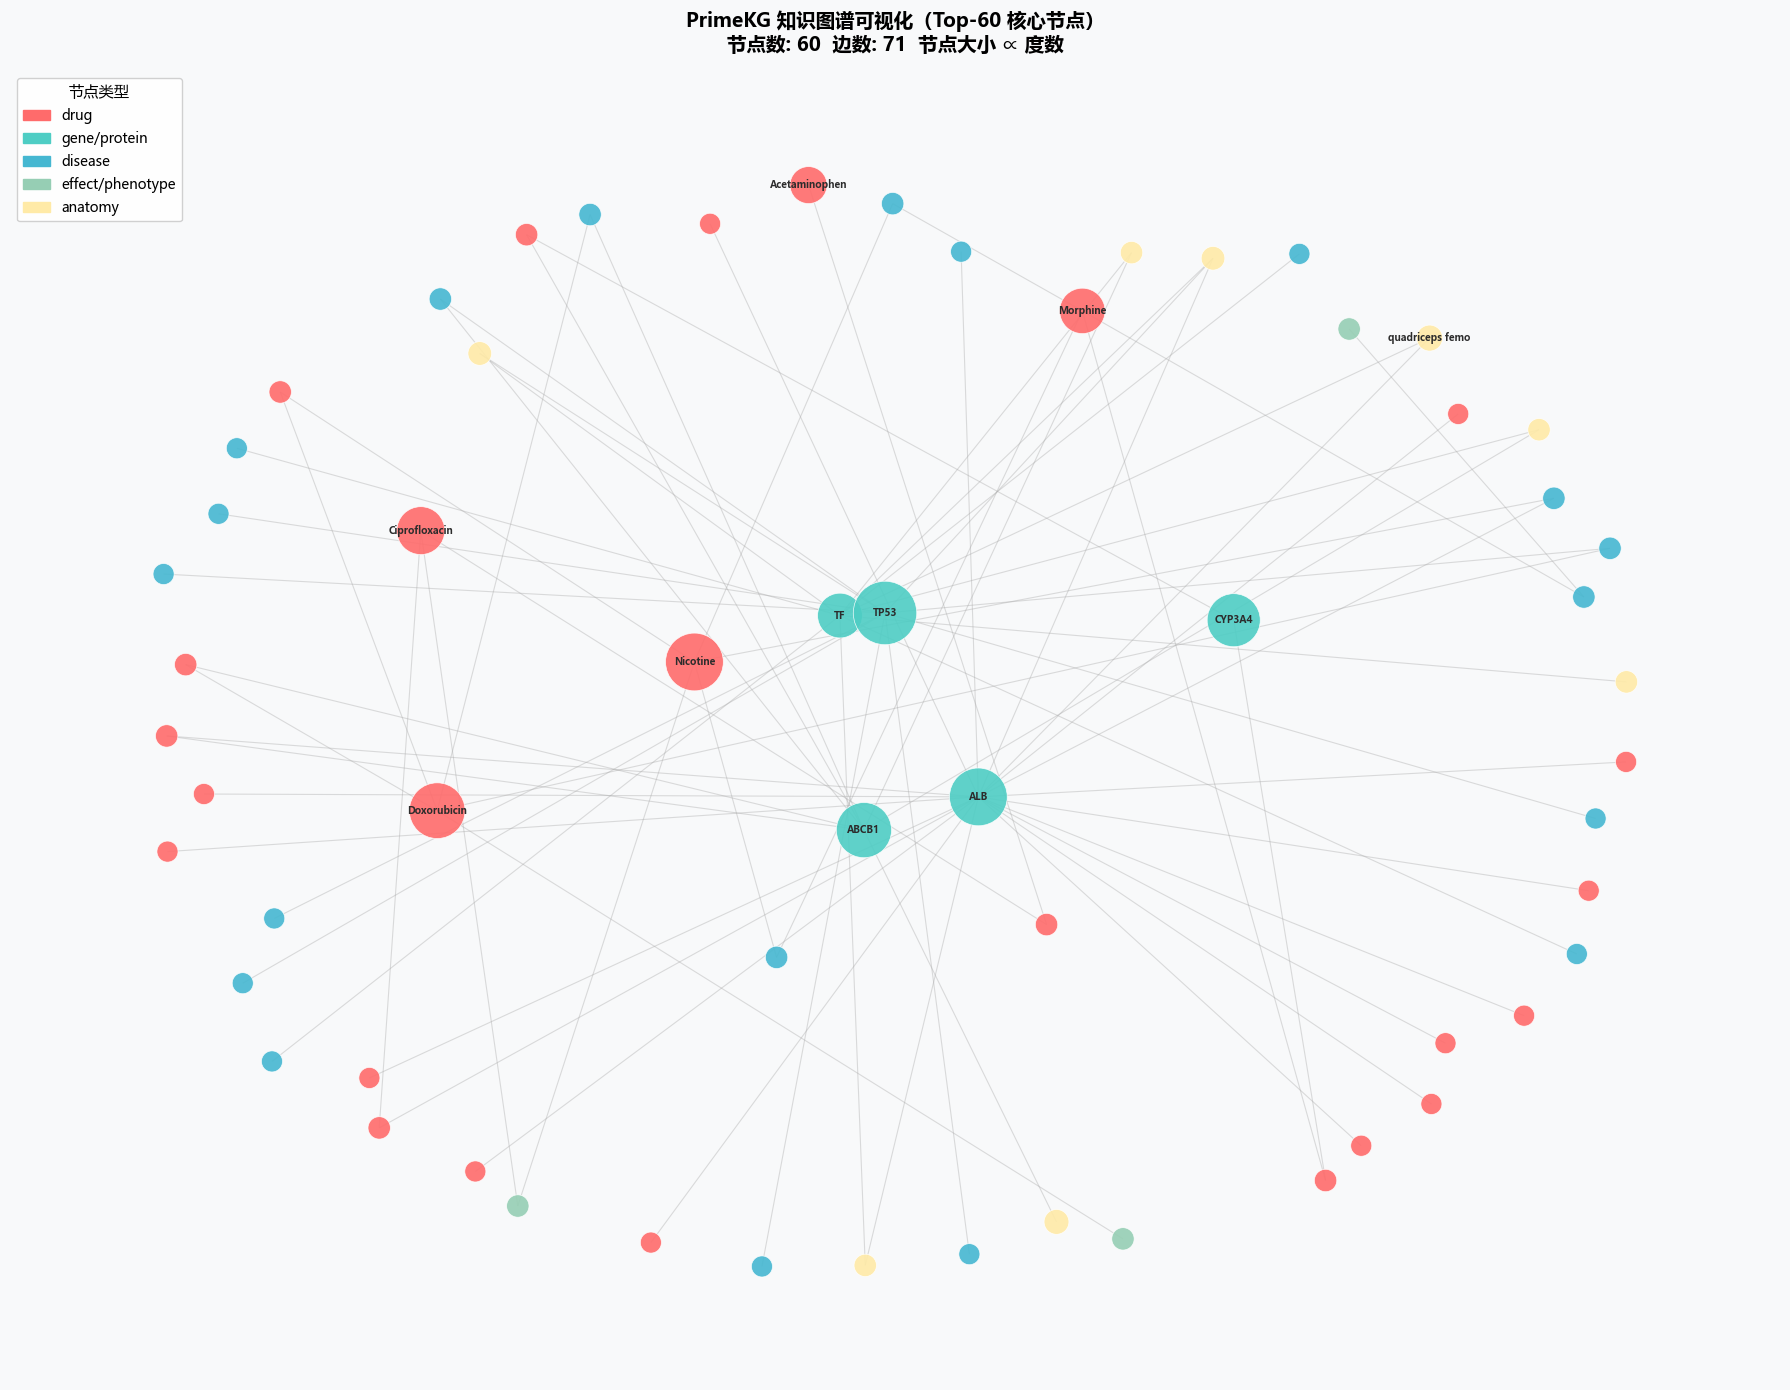

静态图谱已保存至 kg_visualization_static.png


In [10]:
# 7.1 静态可视化：全图（Top-60 高度节点）

TOP_N = 60
top_nodes_set = {n for n, d in
                 sorted(G_lcc.degree(), key=lambda x: x[1], reverse=True)[:TOP_N]}
G_viz = G_lcc.subgraph(top_nodes_set).copy()

np.random.seed(42)
pos = nx.spring_layout(G_viz, k=2.0, iterations=80, seed=42)

fig, ax = plt.subplots(figsize=(18, 14))
ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('#f8f9fa')

node_colors = [node_type_colors.get(G_viz.nodes[n].get('node_type', ''), '#cccccc')
               for n in G_viz.nodes()]
node_sizes  = [200 + G_lcc.degree(n) * 30 for n in G_viz.nodes()]

nx.draw_networkx_edges(G_viz, pos, ax=ax,
                       edge_color='#aaaaaa', alpha=0.4, width=0.8, arrows=False)
nx.draw_networkx_nodes(G_viz, pos, ax=ax,
                       node_color=node_colors, node_size=node_sizes,
                       alpha=0.9, linewidths=0.5, edgecolors='white')

# 标注度数较高的节点
label_nodes = {n for n, d in G_lcc.degree() if d >= 5 and n in top_nodes_set}
nx.draw_networkx_labels(G_viz, pos,
                        labels={n: n[:15] for n in label_nodes},
                        ax=ax, font_size=7, font_color='#2c2c2c', font_weight='bold')

legend_patches = [
    mpatches.Patch(color=c, label=t)
    for t, c in node_type_colors.items()
    if any(G_viz.nodes[n].get('node_type') == t for n in G_viz.nodes())
]
ax.legend(handles=legend_patches, loc='upper left', fontsize=10,
          title='节点类型', title_fontsize=11, framealpha=0.9)
ax.set_title(
    f'PrimeKG 知识图谱可视化（Top-{TOP_N} 核心节点）\n'
    f'节点数: {G_viz.number_of_nodes()}  边数: {G_viz.number_of_edges()}  节点大小 ∝ 度数',
    fontsize=14, fontweight='bold', pad=15)
ax.axis('off')
plt.tight_layout()
plt.savefig('kg_visualization_static.png', bbox_inches='tight', dpi=150)
plt.show()
print('静态图谱已保存至 kg_visualization_static.png')

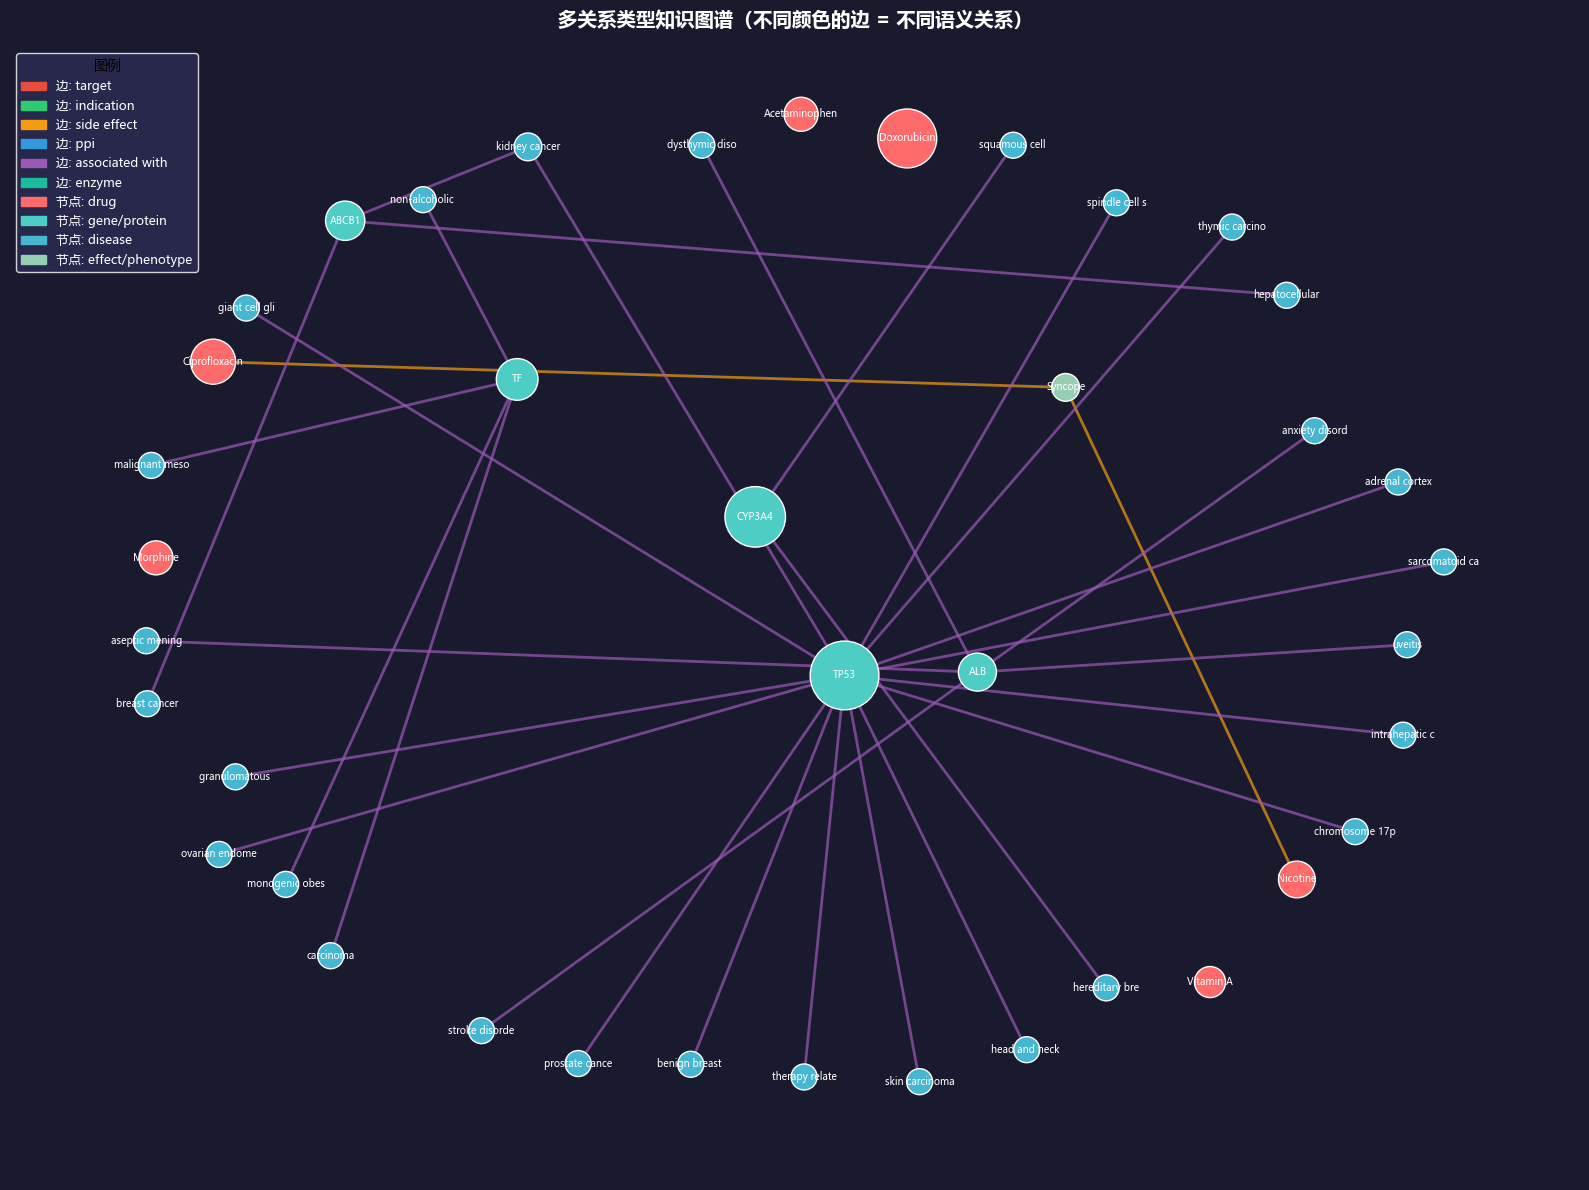

多关系图谱已保存至 kg_visualization_multirel.png


In [11]:
# 7.2 多关系类型可视化（不同颜色的边 = 不同语义）

SHOW_RELS = ['target', 'indication', 'side effect', 'ppi', 'associated with', 'enzyme']
rel_edge_colors = {
    'target':          '#E74C3C',
    'indication':      '#2ECC71',
    'side effect':     '#F39C12',
    'ppi':             '#3498DB',
    'associated with': '#9B59B6',
    'enzyme':          '#1ABC9C',
}

df_viz = df_sample[df_sample['display_relation'].isin(SHOW_RELS)]
G_rel  = nx.Graph()
for _, row in df_viz.iterrows():
    G_rel.add_node(row['x_name'], node_type=row['x_type'])
    G_rel.add_node(row['y_name'], node_type=row['y_type'])
    G_rel.add_edge(row['x_name'], row['y_name'], relation=row['display_relation'])

top40 = {n for n, d in sorted(G_rel.degree(), key=lambda x: x[1], reverse=True)[:40]}
G_sub = G_rel.subgraph(top40).copy()
pos2  = nx.spring_layout(G_sub, k=2.5, iterations=100, seed=42)

fig, ax = plt.subplots(figsize=(16, 12))
ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#1a1a2e')

for rel, color in rel_edge_colors.items():
    edges = [(u, v) for u, v, d in G_sub.edges(data=True) if d.get('relation') == rel]
    if edges:
        nx.draw_networkx_edges(G_sub, pos2, edgelist=edges, ax=ax,
                               edge_color=color, alpha=0.7, width=2.0, arrows=False)

nc2 = [node_type_colors.get(G_sub.nodes[n].get('node_type', ''), '#888888')
       for n in G_sub.nodes()]
ns2 = [300 + G_rel.degree(n) * 50 for n in G_sub.nodes()]
nx.draw_networkx_nodes(G_sub, pos2, ax=ax, node_color=nc2, node_size=ns2,
                       alpha=1.0, edgecolors='white', linewidths=1)
nx.draw_networkx_labels(G_sub, pos2,
                        labels={n: n[:14] for n in G_sub.nodes()},
                        ax=ax, font_size=7, font_color='white')

edge_patches = [mpatches.Patch(color=c, label=f'边: {r}')
                for r, c in rel_edge_colors.items()]
node_patches = [mpatches.Patch(color=c, label=f'节点: {t}')
                for t, c in node_type_colors.items()
                if any(G_sub.nodes[n].get('node_type') == t for n in G_sub.nodes())]
ax.legend(handles=edge_patches + node_patches, loc='upper left', fontsize=9,
          facecolor='#2c2c54', edgecolor='white', labelcolor='white', title='图例')
ax.set_title('多关系类型知识图谱（不同颜色的边 = 不同语义关系）',
             fontsize=14, fontweight='bold', color='white', pad=15)
ax.axis('off')
plt.tight_layout()
plt.savefig('kg_visualization_multirel.png', bbox_inches='tight', dpi=150)
plt.show()
print('多关系图谱已保存至 kg_visualization_multirel.png')

In [12]:
# 7.3 交互式可视化（pyvis）—— 可在浏览器中拖拽、缩放、悬停查看属性

try:
    from pyvis.network import Network

    TOP_PYVIS = 80
    top_vis = {n for n, d in
               sorted(G_lcc.degree(), key=lambda x: x[1], reverse=True)[:TOP_PYVIS]}
    G_pv = G_lcc.subgraph(top_vis).copy()

    net = Network(height='750px', width='100%', bgcolor='#1a1a2e',
                  font_color='white', notebook=True, cdn_resources='in_line')
    net.set_options("""
    var options = {
      "physics": {
        "forceAtlas2Based": {"gravitationalConstant": -80,
                             "springLength": 120, "springConstant": 0.08},
        "solver": "forceAtlas2Based",
        "stabilization": {"iterations": 200}
      }
    }
    """)

    edge_rel_map = {}
    for _, row in df_sample.iterrows():
        edge_rel_map[(row['x_name'], row['y_name'])] = row['display_relation']
        edge_rel_map[(row['y_name'], row['x_name'])] = row['display_relation']

    edge_colors_pv = {
        'target': '#E74C3C', 'indication': '#2ECC71', 'side effect': '#F39C12',
        'ppi': '#3498DB', 'associated with': '#9B59B6', 'enzyme': '#1ABC9C',
        'expression present': '#F8C471', 'synergistic interaction': '#EC407A',
        'interacts with': '#AB47BC', 'parent-child': '#78909C',
        'phenotype present': '#66BB6A', 'contraindication': '#EF5350',
        'carrier': '#26C6DA', 'transporter': '#FFA726', 'off-label use': '#D4E157',
        'phenotype absent': '#BDBDBD', 'expression absent': '#90A4AE',
        'linked to': '#FF7043',
    }

    for node in G_pv.nodes():
        ntype = G_pv.nodes[node].get('node_type', 'unknown')
        deg   = G_lcc.degree(node)
        net.add_node(node, label=node[:20],
                     title=f'<b>{node}</b><br>类型: {ntype}<br>度数: {deg}',
                     color=node_type_colors.get(ntype, '#888888'),
                     size=8 + deg * 1.5)

    for u, v in G_pv.edges():
        rel = edge_rel_map.get((u, v), 'unknown')
        net.add_edge(u, v, title=rel,
                     color=edge_colors_pv.get(rel, '#888888'), width=1.5)

    net.save_graph('kg_interactive.html')
    print('交互式图谱已生成：kg_interactive.html')
    print('在浏览器中打开该文件，可拖拽/缩放/悬停查看节点信息！')

    from IPython.display import IFrame
    display(IFrame('kg_interactive.html', width='100%', height='760px'))

except ImportError:
    print('pyvis 未安装，跳过交互式可视化')
    print('运行以下命令安装：pip install pyvis')

交互式图谱已生成：kg_interactive.html
在浏览器中打开该文件，可拖拽/缩放/悬停查看节点信息！


---
## 第七步：以「Acetaminophen」为中心的局部图谱

### 知识点：局部子图（Ego Graph）

以某个节点为中心，取其 **k 跳邻居**构成的子图称为 **Ego Graph**。  
它展示了该实体的「知识邻域」，是理解单个实体在图谱中地位的常用工具：

- **1-hop 邻居**：直接关联的实体（Acetaminophen 的直接靶点、副作用等）
- **2-hop 邻居**：通过一个中间节点间接关联的实体（如靶点的相关疾病）

以 Acetaminophen 为中心：
  1-hop: 18 节点, 17 边
  2-hop: 19 节点, 18 边
  直接相邻的 1-hop 邻居：
    [disease] common cold -- (indication)
    [disease] attention deficit hyperactivity disorder, inattentive type -- (linked to)
    [disease] cognitive disorder -- (linked to)
    [disease] fibromyalgia -- (off-label use)
    [disease] obsolete vascular headache -- (off-label use)
    [effect/phenotype] Erythroderma -- (side effect)
    [effect/phenotype] Hyperkinetic movements -- (side effect)
    [effect/phenotype] Incoordination -- (side effect)
    [drug] Flomoxef -- (synergistic interaction)
    [drug] Ibutilide -- (synergistic interaction)
    [drug] Gadodiamide -- (synergistic interaction)
    [disease] myofascial pain syndrome -- (off-label use)
    [drug] Norfloxacin -- (synergistic interaction)
    [drug] Ceftriaxone -- (synergistic interaction)
    [drug] Bepridil -- (synergistic interaction)
    [gene/protein] PTGES3 -- (target)
    [gene/protein] PTGS2 -- (target)


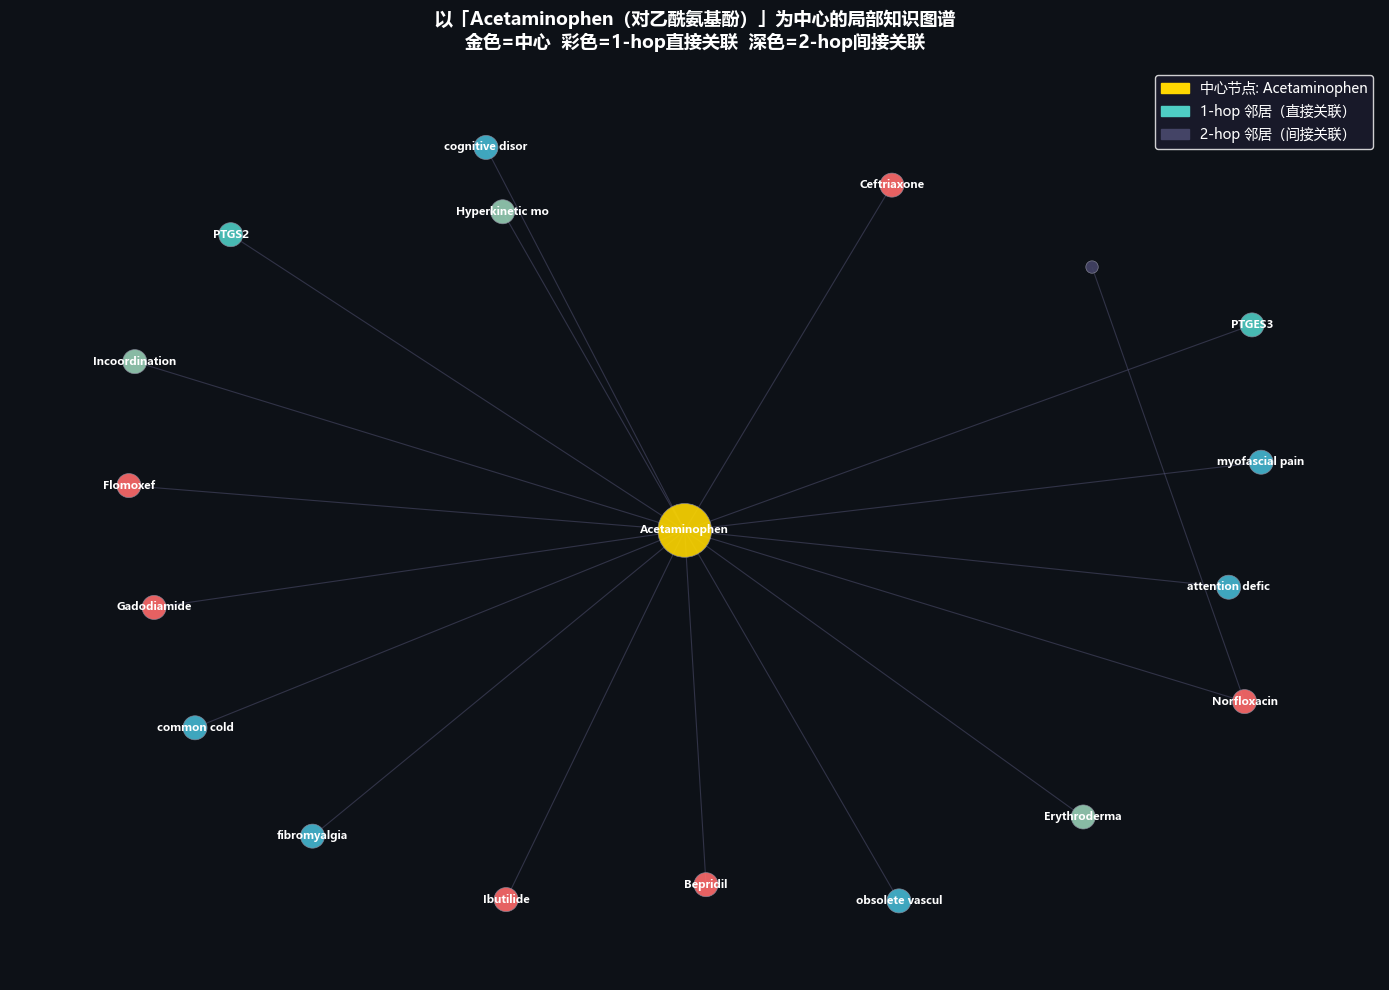

Ego图谱已保存至 ego_graph_acetaminophen.png


In [13]:
# 8.1 构建以 Acetaminophen 为中心的 2-hop Ego Graph

CENTER_NODE = 'Acetaminophen'

if CENTER_NODE in G_simple:
    ego1 = nx.ego_graph(G_simple, CENTER_NODE, radius=1)

    # 2-hop 邻居可能过多，限制规模：每个 1-hop 邻居最多取 3 个 2-hop 邻居
    hop1_set   = set(ego1.nodes())
    hop2_nodes = set(hop1_set)
    for n1 in list(hop1_set):
        for n2 in list(G_simple.neighbors(n1))[:3]:
            hop2_nodes.add(n2)
    ego2 = G_simple.subgraph(hop2_nodes).copy()

    print(f'以 {CENTER_NODE} 为中心：')
    print(f'  1-hop: {ego1.number_of_nodes()} 节点, {ego1.number_of_edges()} 边')
    print(f'  2-hop: {ego2.number_of_nodes()} 节点, {ego2.number_of_edges()} 边')
    print(f'  直接相邻的 1-hop 邻居：')
    for neighbor in list(G_simple.neighbors(CENTER_NODE)):
        ntype = G_simple.nodes[neighbor].get('node_type', '?')
        # 查找关系类型
        rel_rows = df_sample[
            ((df_sample['x_name'] == CENTER_NODE) & (df_sample['y_name'] == neighbor)) |
            ((df_sample['x_name'] == neighbor) & (df_sample['y_name'] == CENTER_NODE))
        ]
        rels = rel_rows['display_relation'].unique()
        print(f'    [{ntype}] {neighbor} -- ({", ".join(rels)})')

    # 布局
    pos_ego = nx.spring_layout(ego2, k=2.5, seed=42)
    pos_ego[CENTER_NODE] = np.array([0.0, 0.0])

    fig, ax = plt.subplots(figsize=(14, 10))
    ax.set_facecolor('#0d1117')
    fig.patch.set_facecolor('#0d1117')

    hop_color = {
        n: ('#FFD700' if n == CENTER_NODE else
            node_type_colors.get(ego2.nodes[n].get('node_type', ''), '#4ECDC4')
            if n in hop1_set else '#444466')
        for n in ego2.nodes()
    }
    hop_size  = {
        n: (1500 if n == CENTER_NODE else 300 if n in hop1_set else 80)
        for n in ego2.nodes()
    }

    nx.draw_networkx_edges(ego2, pos_ego, ax=ax, edge_color='#555577',
                           alpha=0.5, width=0.8, arrows=False)
    nx.draw_networkx_nodes(ego2, pos_ego, ax=ax,
                           node_color=[hop_color[n] for n in ego2.nodes()],
                           node_size=[hop_size[n] for n in ego2.nodes()],
                           alpha=0.9, edgecolors='#888899', linewidths=0.5)
    nx.draw_networkx_labels(ego2, pos_ego,
                            labels={n: n[:15] for n in hop1_set | {CENTER_NODE}},
                            ax=ax, font_size=8, font_color='white', font_weight='bold')

    legend_items = [
        mpatches.Patch(color='#FFD700', label=f'中心节点: {CENTER_NODE}'),
        mpatches.Patch(color='#4ECDC4', label='1-hop 邻居（直接关联）'),
        mpatches.Patch(color='#444466', label='2-hop 邻居（间接关联）'),
    ]
    ax.legend(handles=legend_items, loc='upper right', fontsize=10,
              facecolor='#1c1c2e', edgecolor='white', labelcolor='white')
    ax.set_title(
        f'以「{CENTER_NODE}（对乙酰氨基酚）」为中心的局部知识图谱\n'
        '金色=中心  彩色=1-hop直接关联  深色=2-hop间接关联',
        fontsize=13, color='white', fontweight='bold', pad=15)
    ax.axis('off')
    plt.tight_layout()
    plt.savefig('ego_graph_acetaminophen.png', bbox_inches='tight', dpi=150)
    plt.show()
    print('Ego图谱已保存至 ego_graph_acetaminophen.png')
else:
    print(f'节点 {CENTER_NODE} 不在采样子图中')

---
## 第八步：知识图谱的典型应用

### 知识点：知识图谱能做什么？

| 应用场景 | 技术方法 | 示例 |
|---------|---------|------|
| **实体查询** | 直接图遍历 | 查询某药物的所有靶点 |
| **关系推理** | 最短路径、随机游走 | 发现药物与疾病的间接联系 |
| **链接预测** | 共同邻居、图神经网络 | 预测新的药物-靶点关系 |
| **药物重定向** | 路径分析 | 老药新用（如阿司匹林抗癌）|
| **问答系统** | 图谱+语言模型 | 医学问答、临床决策支持 |

In [14]:
# 9.1 应用一：实体查询

def query_entity(df_edges, entity_name):
    """查询某实体在知识图谱中的所有关联信息"""
    results = defaultdict(list)
    as_head = df_edges[df_edges['x_name'] == entity_name]
    for _, row in as_head.iterrows():
        results[row['display_relation']].append(
            f"{row['y_name']} ({row['y_type']})")
    as_tail = df_edges[df_edges['y_name'] == entity_name]
    for _, row in as_tail.iterrows():
        results[f"<-{row['display_relation']}"].append(
            f"{row['x_name']} ({row['x_type']})")
    return dict(results)

result = query_entity(df_sample, 'Acetaminophen')
print('=== 实体查询：Acetaminophen（对乙酰氨基酚）===')
for rel, entities in sorted(result.items()):
    print(f'\n  [{rel}]')
    for e in entities[:5]:
        print(f'    -> {e}')
    if len(entities) > 5:
        print(f'    ... 共 {len(entities)} 个')

=== 实体查询：Acetaminophen（对乙酰氨基酚）===

  [<-linked to]
    -> attention deficit hyperactivity disorder, inattentive type (disease)
    -> cognitive disorder (disease)

  [<-off-label use]
    -> myofascial pain syndrome (disease)
    -> fibromyalgia (disease)

  [<-synergistic interaction]
    -> Ceftriaxone (drug)
    -> Bepridil (drug)
    -> Norfloxacin (drug)

  [<-target]
    -> PTGES3 (gene/protein)
    -> PTGS2 (gene/protein)

  [indication]
    -> common cold (disease)

  [linked to]
    -> attention deficit hyperactivity disorder, inattentive type (disease)
    -> cognitive disorder (disease)

  [off-label use]
    -> fibromyalgia (disease)
    -> obsolete vascular headache (disease)

  [side effect]
    -> Erythroderma (effect/phenotype)
    -> Hyperkinetic movements (effect/phenotype)
    -> Incoordination (effect/phenotype)

  [synergistic interaction]
    -> Flomoxef (drug)
    -> Ibutilide (drug)
    -> Gadodiamide (drug)


In [15]:
# 9.2 应用二：实体间路径推理

def find_path_with_relations(G_undirected, df_edges, source, target, max_hop=3):
    """找两节点间的最短路径，并标注每步的关系类型"""
    try:
        path = nx.shortest_path(G_undirected, source, target)
    except (nx.NetworkXNoPath, nx.NodeNotFound) as e:
        return None, str(e)

    if len(path) - 1 > max_hop:
        return None, f'路径长度({len(path)-1})超过最大跳数({max_hop})'

    path_with_rels = []
    for u, v in zip(path[:-1], path[1:]):
        row = df_edges[
            ((df_edges['x_name'] == u) & (df_edges['y_name'] == v)) |
            ((df_edges['x_name'] == v) & (df_edges['y_name'] == u))
        ]
        rel = row['display_relation'].iloc[0] if len(row) > 0 else '?'
        path_with_rels.append((u, rel, v))
    return path_with_rels, None

print('=== 应用示例：实体间关系路径推理 ===')
print()
query_pairs = [
    ('Acetaminophen', 'TP53'),
    ('Doxorubicin',   'ABCB1'),
    ('Nicotine',      'CYP3A4'),
]
for src, tgt in query_pairs:
    path, err = find_path_with_relations(G_simple, df_sample, src, tgt)
    print(f'  {src} -> {tgt}:')
    if path:
        step_str = ' -> '.join(
            f'{u} --[{r}]-->' for u, r, v in path) + f' {path[-1][2]}'
        print(f'    路径 ({len(path)} 跳): {step_str}')
    else:
        print(f'    未找到路径: {err}')
    print()

=== 应用示例：实体间关系路径推理 ===

  Acetaminophen -> TP53:
    未找到路径: 路径长度(6)超过最大跳数(3)

  Doxorubicin -> ABCB1:
    路径 (2 跳): Doxorubicin --[off-label use]--> -> hepatocellular carcinoma --[associated with]--> ABCB1

  Nicotine -> CYP3A4:
    未找到路径: 路径长度(4)超过最大跳数(3)



In [16]:
# 9.3 应用三：基于共同邻居的链接预测
# 原理：若 A 和 C 有很多共同邻居 B，则 A-C 之间可能存在未知关系

def predict_links(G_u, node, top_k=10):
    """基于共同邻居数预测与某节点最可能发生关联的节点"""
    if node not in G_u:
        return []
    existing = set(G_u.neighbors(node))
    candidates = Counter()
    for nb in existing:
        for cand in G_u.neighbors(nb):
            if cand != node and cand not in existing:
                candidates[cand] += 1
    return candidates.most_common(top_k)

print('=== 应用示例：链接预测（预测 Acetaminophen 的潜在关联）===')
print('原理：共同邻居越多 -> 潜在关联越强')
print()
predictions = predict_links(G_simple, 'Acetaminophen', top_k=10)

print(f'  {"候选节点":<28} {"共同邻居数":>10}  {"节点类型"}')
print(f'  {"-"*60}')
for cand, score in predictions:
    ntype = G_simple.nodes.get(cand, {}).get('node_type', 'unknown')
    print(f'  {cand:<28} {score:>10}  {ntype}')

=== 应用示例：链接预测（预测 Acetaminophen 的潜在关联）===
原理：共同邻居越多 -> 潜在关联越强

  候选节点                              共同邻居数  节点类型
  ------------------------------------------------------------
  Ciprofloxacin                         1  drug


---
## 第九步：总结与思考题

### 本案例总结

| 步骤 | 内容 | 核心概念 |
|------|------|----------|
| 数据加载 | 读取 kg_demo.csv，540 条三元组 | 三元组 (h, r, t)、实体类型、关系类型 |
| 关系统计 | 18 种关系均衡覆盖 | 多关系图、Demo vs 完整数据对比 |
| 图谱构建 | NetworkX MultiDiGraph | 有向异质图、节点/边属性 |
| 统计分析 | 度分布、中心性 | 幂律分布、度/介数中心性 |
| 可视化 | 静态+交互式+Ego图 | 力导向布局、节点着色 |
| 应用示例 | 查询/路径/链接预测 | 图遍历、最短路径 |

---

### 思考题

**1. 概念题**  
什么是知识图谱的「三元组」？请举一个生活中的例子（不限于医学领域），并描述其头实体、关系、尾实体。

**2. 分析题**  
在度分布的对数坐标图中，我们观察到近似**幂律分布**的特征（P(k) ~ k^{-γ}）。这意味着什么？真实世界的网络（社交网络、互联网）为什么常具有这种特性？

**3. 工程题**  
本案例的 Demo 数据采用了「枢纽节点锚点采样」策略。为什么不直接随机采样 540 条边？  
请对比两种采样方式，分析对知识图谱可视化效果的影响。

**4. 应用题**  
在生物医学知识图谱中，「最短路径推理」有什么实际意义？  
提示：考虑「药物重定向（Drug Repurposing）」——如何利用路径推理发现老药的新用途？

**5. 扩展题**  
当前案例使用简单的「共同邻居」进行链接预测。真实研究中还有哪些更强大的方法？  
提示：了解 TransE、RotatE 等**知识图谱嵌入（Knowledge Graph Embedding）**方法，  
以及 GNN（图神经网络）在此任务中的应用。

---

### 数据集获取

| 资源 | 地址 |
|------|------|
| 完整 PrimeKG 数据下载 | https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/IXA7BM |
| 代码与文档 | https://github.com/mims-harvard/PrimeKG |
| 原始论文 | https://www.nature.com/articles/s41597-023-01960-3 |

---

### 延伸阅读

- **知识图谱综述**：Hogan et al., "Knowledge Graphs" (ACM Computing Surveys, 2021)
- **图神经网络**：Hamilton et al., "Graph Representation Learning" (Morgan & Claypool, 2020)
- **链接预测**：Wang et al., "Knowledge Graph Embedding: A Survey" (IEEE TKDE, 2017)

In [17]:
# 最终汇总：输出文件清单
import os

output_files = [
    ('relation_distribution.png',  '关系类型分布图'),
    ('node_overlap_heatmap.png',   '节点重叠热力图'),
    ('degree_analysis.png',        '度分布分析图'),
    ('centrality_analysis.png',    '中心性分析图'),
    ('kg_visualization_static.png','静态知识图谱'),
    ('kg_visualization_multirel.png', '多关系知识图谱'),
    ('ego_graph_acetaminophen.png','Ego局部图谱'),
    ('kg_interactive.html',        '交互式图谱（浏览器打开）'),
]

print('=' * 60)
print('          知识图谱教学案例 -- 输出文件汇总')
print('=' * 60)
for fname, desc in output_files:
    status = '存在' if os.path.exists(fname) else '未生成'
    size = f'({os.path.getsize(fname)/1024:.1f} KB)' if os.path.exists(fname) else ''
    mark = '[OK]' if os.path.exists(fname) else '[--]'
    print(f'  {mark} {fname:<42} {desc} {size}')

print()
print('教学案例运行完成！')

          知识图谱教学案例 -- 输出文件汇总
  [OK] relation_distribution.png                  关系类型分布图 (139.5 KB)
  [--] node_overlap_heatmap.png                   节点重叠热力图 
  [OK] degree_analysis.png                        度分布分析图 (101.4 KB)
  [OK] centrality_analysis.png                    中心性分析图 (84.0 KB)
  [OK] kg_visualization_static.png                静态知识图谱 (660.0 KB)
  [OK] kg_visualization_multirel.png              多关系知识图谱 (467.6 KB)
  [OK] ego_graph_acetaminophen.png                Ego局部图谱 (249.4 KB)
  [OK] kg_interactive.html                        交互式图谱（浏览器打开） (711.6 KB)

教学案例运行完成！
